### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [3]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/AQI-and-Lat-Long-of-Countries.csv')

In [5]:
df.shape

(16695, 7)

In [6]:
df.head()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,lat,lng
0,51,1,36,0,51,44.7444,44.2031
1,41,1,5,1,41,-5.2900,-44.4900
2,41,1,5,1,41,-11.2958,-41.9869
3,66,1,39,2,66,37.1667,15.1833
4,34,1,34,0,20,53.0167,20.8833


### Step 3: Exploaring Data

Basic Info

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AQI Value,16695.0,62.998682,43.091971,7.0000,38.50000,52.0000,69.0000,500.0000
CO AQI Value,16695.0,1.342138,2.371379,0.0000,1.00000,1.0000,1.0000,133.0000
Ozone AQI Value,16695.0,31.767355,22.839343,0.0000,20.00000,29.0000,38.0000,222.0000
NO2 AQI Value,16695.0,3.819647,5.880677,0.0000,0.00000,2.0000,5.0000,91.0000
PM2.5 AQI Value,16695.0,59.821324,43.208298,0.0000,34.00000,52.0000,69.0000,500.0000
lat,16695.0,30.267148,22.947398,-54.8019,16.51545,38.8158,46.6833,70.7670
lng,16695.0,-3.944485,73.037148,-171.7500,-75.18000,5.6431,36.2750,178.0178


In [12]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [13]:
feature_info

,null,unique,type
AQI Value,0,282,int64
CO AQI Value,0,31,int64
Ozone AQI Value,0,203,int64
NO2 AQI Value,0,56,int64
PM2.5 AQI Value,0,298,int64
lat,0,14135,float64
lng,0,14896,float64


Target Distribution

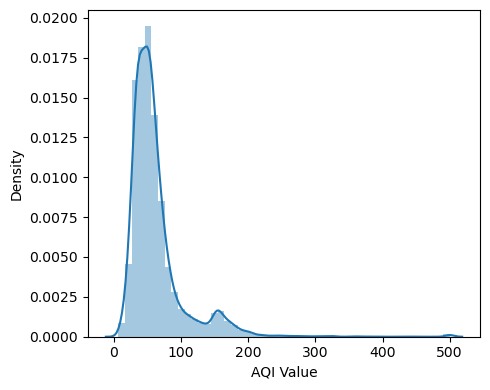

In [18]:
plt.figure(figsize=(5, 4))
sns.distplot(df['AQI Value'])
plt.tight_layout()

Number Distribution

In [21]:
num_cols = df.columns.to_list()

In [22]:
num_cols.remove('AQI Value')

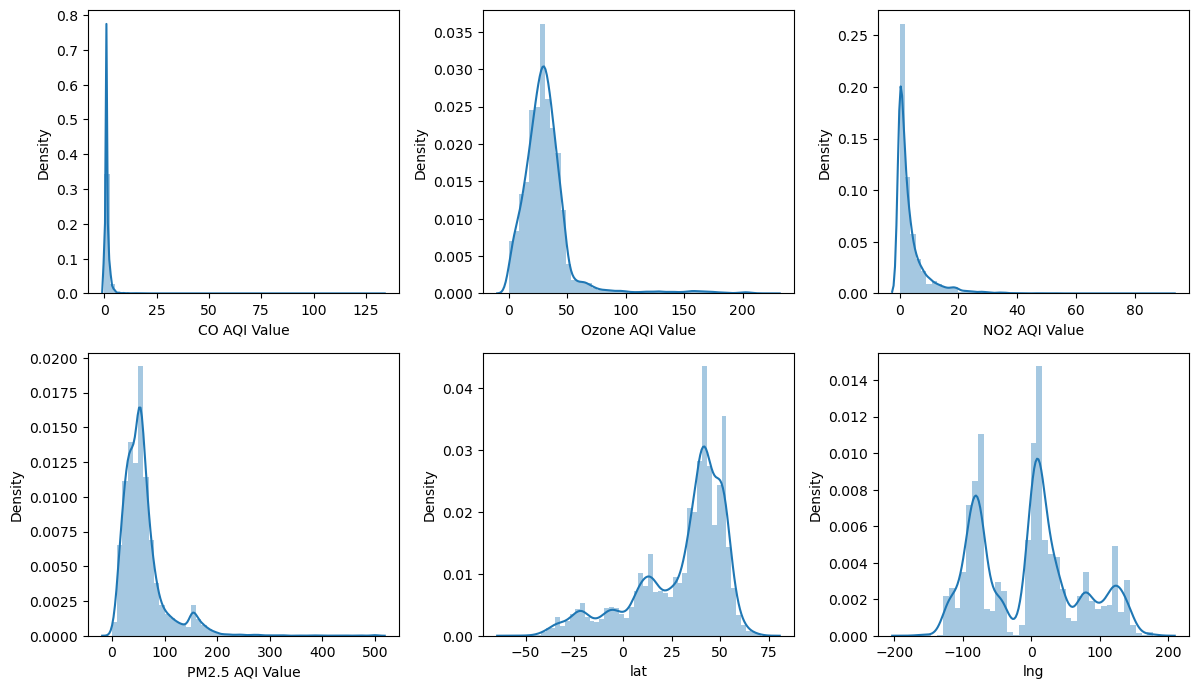

In [29]:
plt.figure(figsize=(12, 7))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.distplot(df[col])
plt.tight_layout()

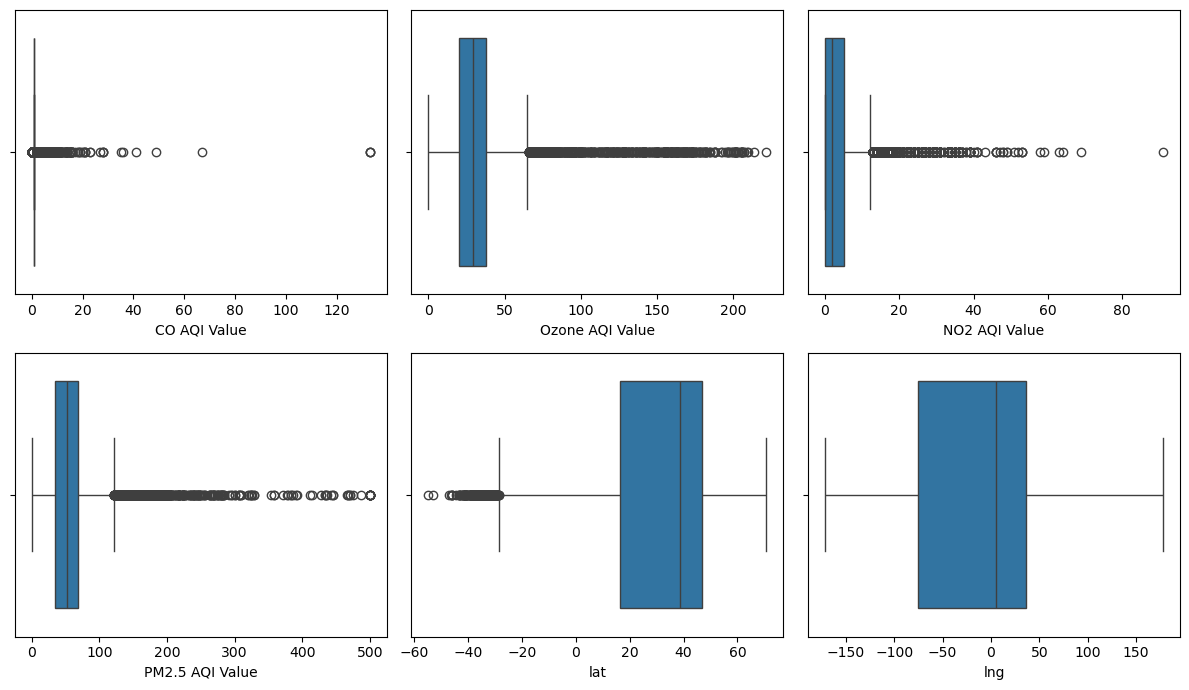

In [30]:
plt.figure(figsize=(12, 7))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(df[col], orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [31]:
df.dropna(ignore_index=True, inplace=True)

Heat Map

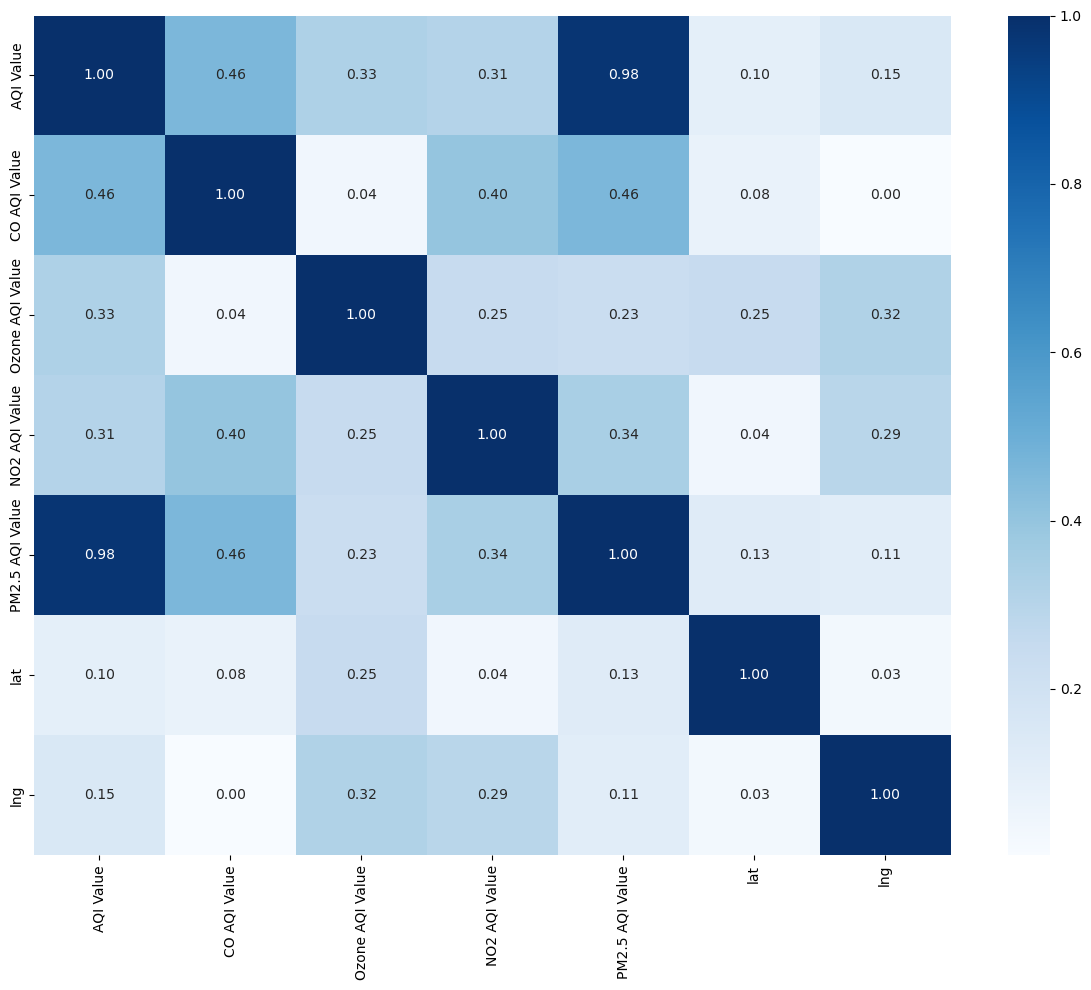

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.Blues
)
plt.tight_layout()

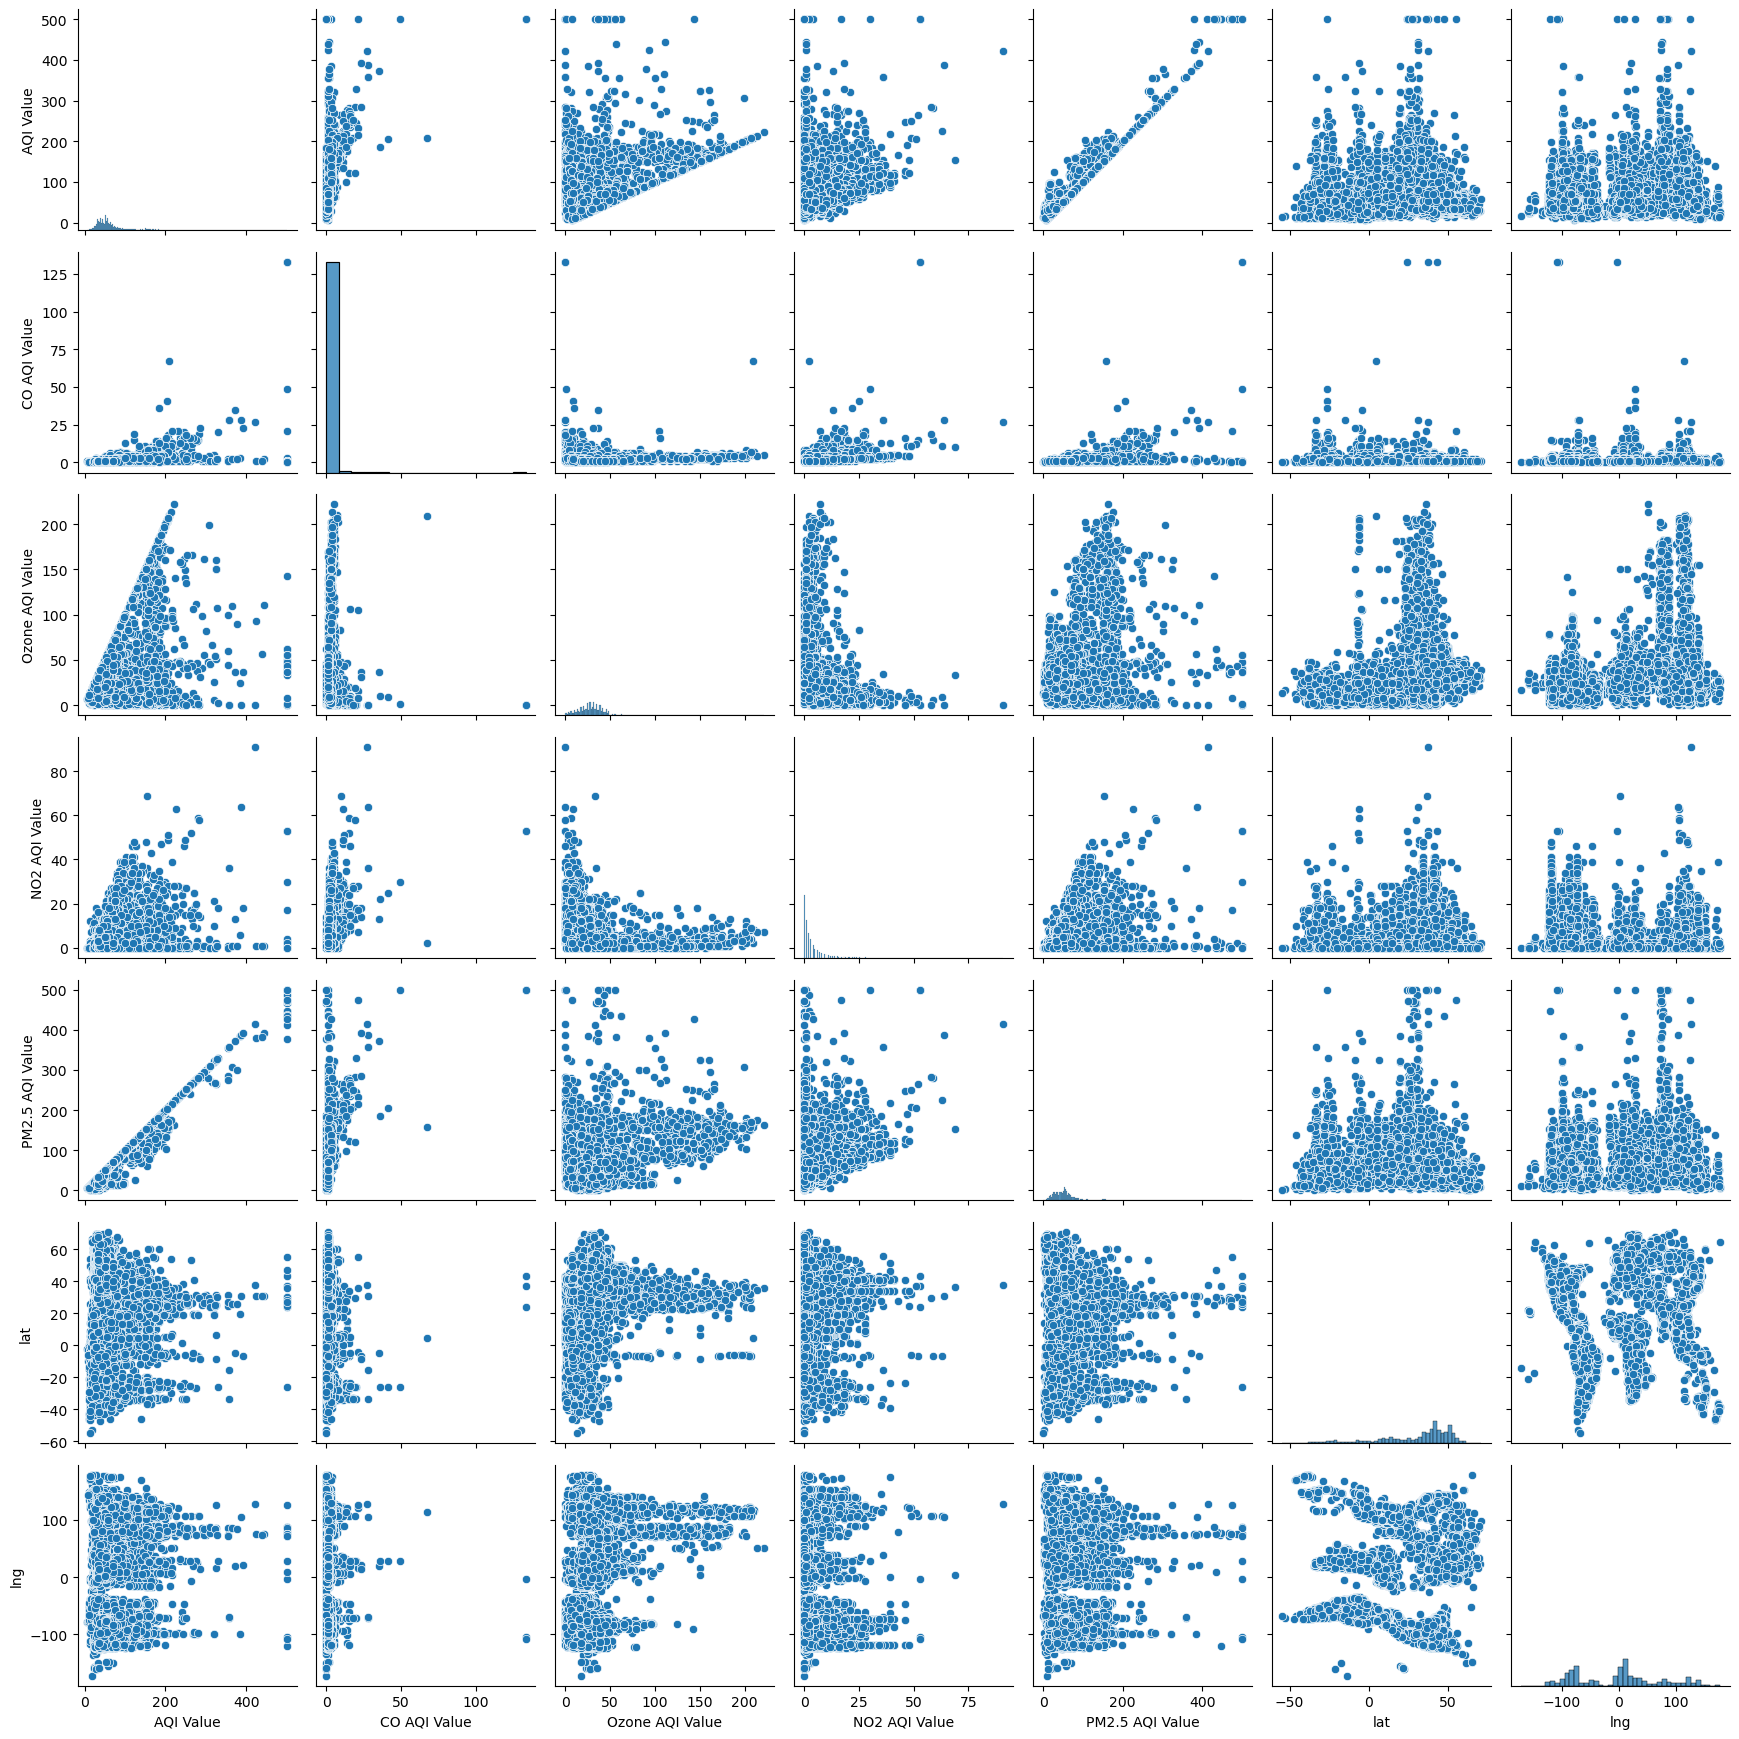

In [36]:
sns.pairplot(df)
plt.tight_layout()

### Step 5: Preparing Data

Select Feature

In [37]:
features = df.drop('AQI Value', axis=1)
target = df['AQI Value']

In [38]:
selector = SmartCorrelatedSelection(threshold=0.9, selection_method='corr_with_target')

In [39]:
features = selector.fit_transform(features, target)

In [40]:
print(f'Current Number of Feature is {features.shape[1]}')

Current Number of Feature is 6


Split Data

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Normalization

In [44]:
scaler = StandardScaler()

In [45]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

Building Model

In [47]:
rfr = RandomForestRegressor(random_state=42)

Training Model

In [48]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Testing Model

In [49]:
y_pred = rfr.predict(X_test)

Evaluate Model

In [51]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

In [53]:
print(f'Mean Absolute Error: {mae:.3f}')
print(f'Mean Squared Error: {mse:.3f}')
print(f'R2 Score: {r2:.3f}')

Mean Absolute Error: 0.088
Mean Squared Error: 2.131
R2 Score: 0.999


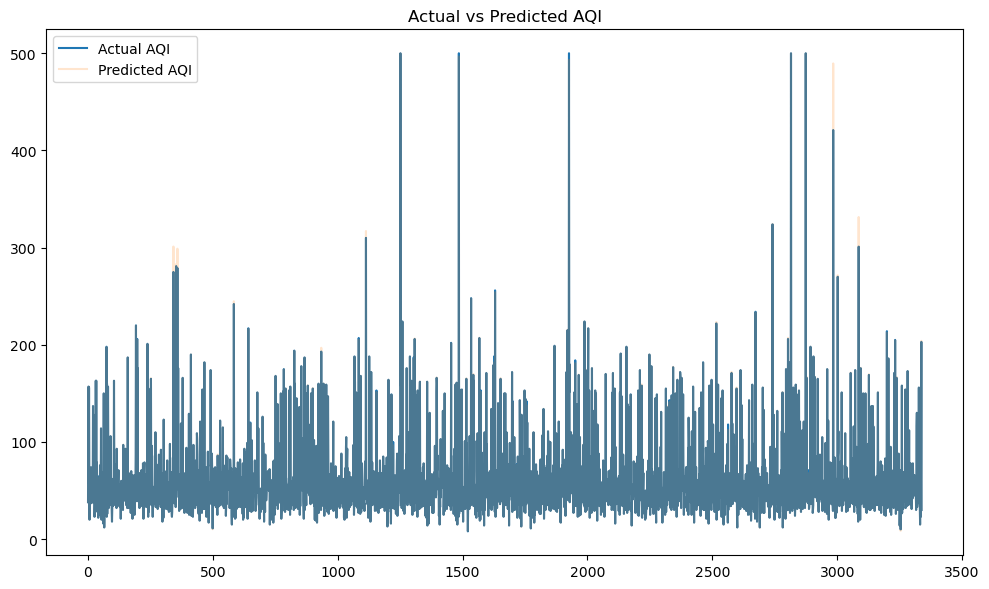

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI', alpha=0.2)
plt.title('Actual vs Predicted AQI')
plt.legend()
plt.tight_layout()